In [1]:
%pip install h5py


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy
from PIL import Image
from scipy import ndimage      
from dnn_app_utils_v3 import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

np.random.seed(1)

In [3]:
train_x_orig, train_y, test_x_orig, test_y, classes = load_data()

In [4]:
classes

array([b'non-cat', b'cat'], dtype='|S7')

y = 0. It's a non-cat picture.


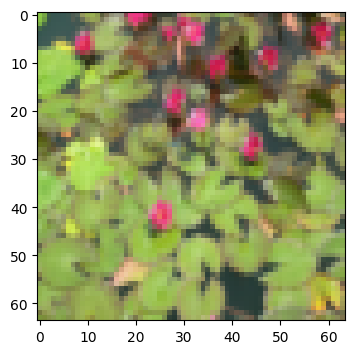

In [5]:
# Example of a picture
index = 18
plt.imshow(train_x_orig[index])
print ("y = " + str(train_y[0,index]) + ". It's a " + classes[train_y[0,index]].decode("utf-8") +  " picture.")

In [6]:
m_train = train_x_orig.shape[0]
num_px = train_x_orig.shape[1]
m_test = test_x_orig.shape[0]

print ("Number of training examples: " + str(m_train))
print ("Number of testing examples: " + str(m_test))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_x_orig shape: " + str(train_x_orig.shape))
print ("train_y shape: " + str(train_y.shape))
print ("test_x_orig shape: " + str(test_x_orig.shape))
print ("test_y shape: " + str(test_y.shape))

Number of training examples: 209
Number of testing examples: 50
Each image is of size: (64, 64, 3)
train_x_orig shape: (209, 64, 64, 3)
train_y shape: (1, 209)
test_x_orig shape: (50, 64, 64, 3)
test_y shape: (1, 50)


As usual, you reshape and standardize the images before feeding them to the network. The code is given in the cell below.

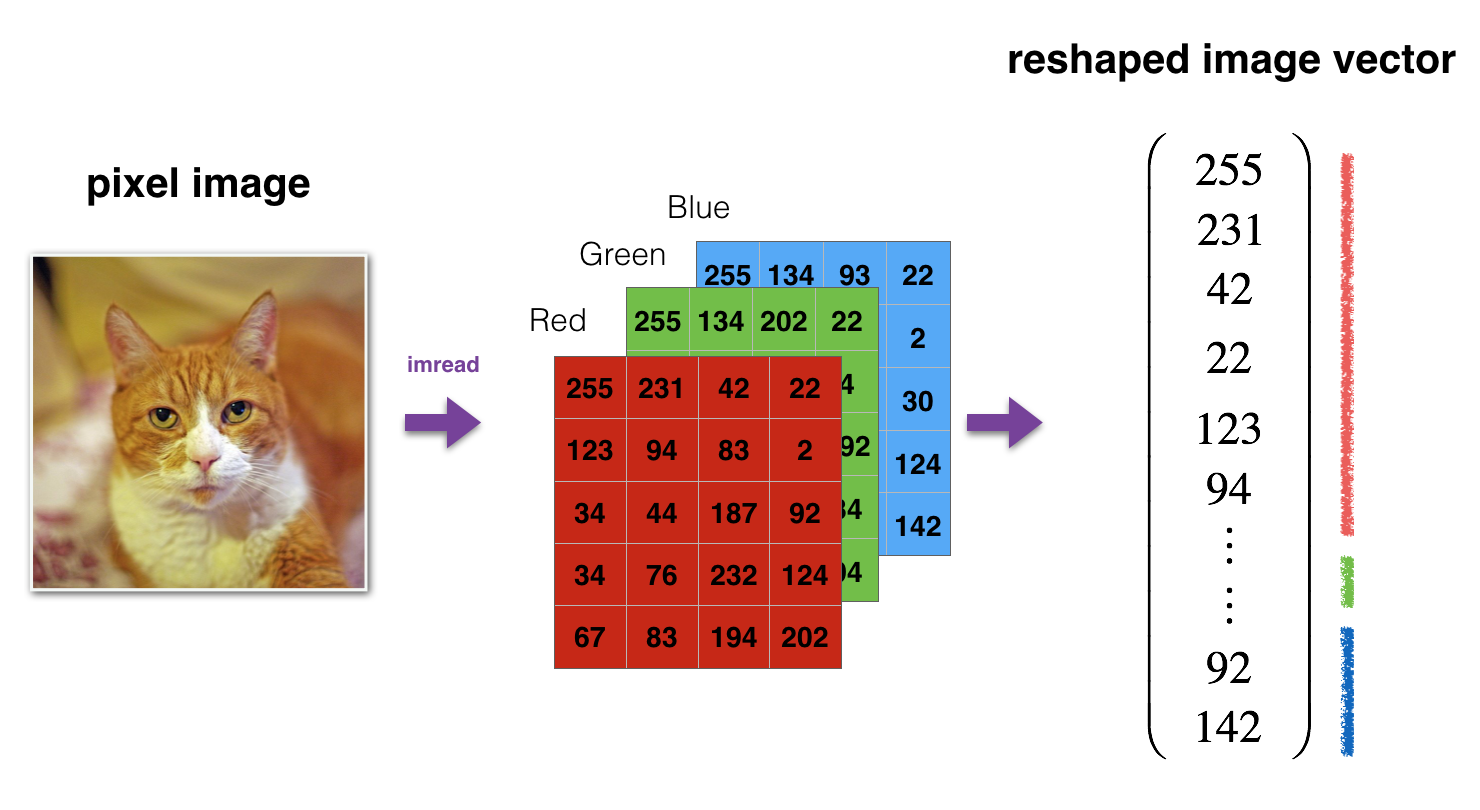

In [7]:
# Reshape the training and test examples 
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0], -1).T   # The "-1" makes reshape flatten the remaining dimensions
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1).T

# Standardize data to have feature values between 0 and 1.
train_x = train_x_flatten/255.
test_x = test_x_flatten/255.

print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape)) 

train_x's shape: (12288, 209)
test_x's shape: (12288, 50)


In [8]:
# 12,288 equals 64×64×3, which is the size of one reshaped image vector.

<u><b>Detailed Architecture</b></u>:
- The input is a (64,64,3) image which is flattened to a vector of size (12288,1).
- The corresponding vector: $[x_0,x_1,...,x_{12287}]^T$ is then multiplied by the weight matrix $W^{[1]}$ and then you add the intercept $b^{[1]}$. The result is called the linear unit.
- Next, take the relu of the linear unit. This process could be repeated several times for each $(W^{[l]}, b^{[l]})$ depending on the model architecture.
- Finally, take the sigmoid of the final linear unit. If it is greater than 0.5, classify it as a cat.

<a name='3-3'></a>
### General Methodology

As usual, you'll follow the Deep Learning methodology to build the model:

1. Initialize parameters / Define hyperparameters
2. Loop for num_iterations:
    a. Forward propagation
    b. Compute cost function
    c. Backward propagation
    d. Update parameters (using parameters, and grads from backprop) 
3. Use trained parameters to predict labels

Now go ahead and implement those two models!

In [25]:
### CONSTANTS DEFINING THE MODEL ####

n_x = 12288     # num_px * num_px * 3 which is the size of the input layer
n_h = 7         # size of the hidden layers 
n_y = 1         # size of the output layer
layers_dims = (n_x, n_h, n_y)
learning_rate = 0.0075

Building a two layer model

In [26]:
# a function for a two layer model

def two_layer_model(X, Y, layers_dims, learning_rate = 0.0075, num_iterations = 3000, print_cost=False):
    """
    Implements a two-layer neural network: LINEAR->RELU->LINEAR->SIGMOID.
    
    Arguments:
    X -- input data, of shape (n_x, number of examples)
    Y -- true "label" vector (containing 1 if cat, 0 if non-cat), of shape (1, number of examples)
    layers_dims -- dimensions of the layers (n_x, n_h, n_y)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- If set to True, this will print the cost every 100 iterations 
    
    Returns:
    parameters -- a dictionary containing W1, W2, b1, and b2
    """
    
    np.random.seed(1)
    grads = {}
    costs = []                              # to keep track of the cost
    m = X.shape[1]                           # number of examples
    (n_x, n_h, n_y) = layers_dims

    # Initialize parameters dictionary, by calling one of the functions you'd previously implemented
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    # Get W1, b1, W2 and b2 from the dictionary parameters.
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]

    # Loop (gradient descent)
    for i in range(0, num_iterations):
        
        # Forward propagation: LINEAR -> RELU -> LINEAR -> SIGMOID. Inputs: "X, W1, b1, W2, b2". Output: "A1, cache1, A2, cache2".

        A1, cache1 = linear_activation_forward(X, W1, b1, activation = "relu")
        A2, cache2 = linear_activation_forward(A1, W2, b2, activation = "sigmoid")
        
        cost = compute_cost(A2, Y)
        
        # Initializing backward propagation
        dA2 = - (np.divide(Y, A2) - np.divide(1 - Y, 1 - A2))
        
        # Backward propagation. Inputs: "dA2, cache2, cache1". Outputs: "dA1, dW2, db2; also dA0 (not used), dW1, db1".

        dA1, dW2, db2 = linear_activation_backward(dA2, cache2, activation = "sigmoid")
        dA0, dW1, db1 = linear_activation_backward(dA1, cache1, activation = "relu")
        
        # Set grads['dWl'] to dW1, grads['db1'] to db1, grads['dW2'] to dW2, grads['db2'] to db2
        grads['dW1'] = dW1
        grads['db1'] = db1
        grads['dW2'] = dW2
        grads['db2'] = db2
        
        # Update parameters.

        parameters = update_parameters(parameters, grads, learning_rate)

        # Retrieve W1, b1, W2, b2 from parameters
        W1 = parameters["W1"]
        b1 = parameters["b1"]
        W2 = parameters["W2"]
        b2 = parameters["b2"]
        
        # Print the cost every 100 iterations and for the last iteration
        if print_cost and (i % 100 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)
            
    return parameters, costs

def plot_costs(costs, learning_rate=0.0075):
    plt.plot(np.squeeze(costs))
    plt.ylabel('cost')
    plt.xlabel('iterations (per hundreds)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()


### Train the model 

Cost after iteration 0: 0.693049735659989
Cost after iteration 100: 0.6464320953428849
Cost after iteration 200: 0.6325140647912677
Cost after iteration 300: 0.6015024920354665
Cost after iteration 400: 0.5601966311605747
Cost after iteration 500: 0.5158304772764729
Cost after iteration 600: 0.47549013139433244
Cost after iteration 700: 0.4339163151225749
Cost after iteration 800: 0.4007977536203891
Cost after iteration 900: 0.35807050113237976
Cost after iteration 1000: 0.33942815383664116
Cost after iteration 1100: 0.3052753636196265
Cost after iteration 1200: 0.2749137728213018
Cost after iteration 1300: 0.24681768210614874
Cost after iteration 1400: 0.19850735037466088
Cost after iteration 1500: 0.17448318112556635
Cost after iteration 1600: 0.17080762978096195
Cost after iteration 1700: 0.11306524562164721
Cost after iteration 1800: 0.09629426845937146
Cost after iteration 1900: 0.08342617959726856
Cost after iteration 2000: 0.07439078704319077
Cost after iteration 2100: 0.0663074

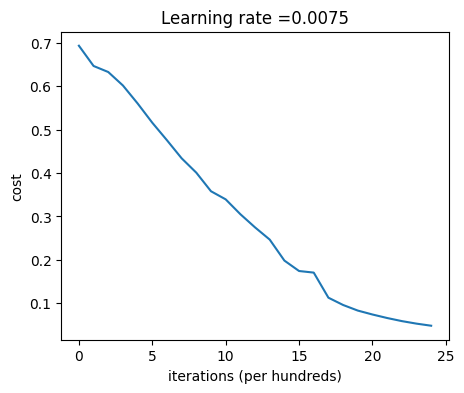

In [24]:
parameters, costs = two_layer_model(train_x, train_y, layers_dims = (n_x, n_h, n_y), num_iterations = 2500, print_cost=True)
plot_costs(costs, learning_rate)

In [27]:
predictions_train = predict(train_x, train_y, parameters)

Accuracy: 0.9999999999999998


In [28]:
predictions_test = predict(test_x, test_y, parameters)

Accuracy: 0.72


Now, building an L-layered model

In [29]:
### CONSTANTS ###
layers_dims = [12288, 20, 7, 5, 1] #  4-layer model

In [30]:
def L_layer_model(X, Y, layers_dims, learning_rate = 0.0075, num_iterations = 3000, print_cost=False):
    """
    Implements a L-layer neural network: [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID.
    
    Arguments:
    X -- input data, of shape (n_x, number of examples)
    Y -- true "label" vector (containing 1 if cat, 0 if non-cat), of shape (1, number of examples)
    layers_dims -- list containing the input size and each layer size, of length (number of layers + 1).
    learning_rate -- learning rate of the gradient descent update rule
    num_iterations -- number of iterations of the optimization loop
    print_cost -- if True, it prints the cost every 100 steps
    
    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """

    np.random.seed(1)
    costs = []                         # keep track of cost
    
    parameters = initialize_parameters_deep(layers_dims)
    
    # Loop (gradient descent)
    for i in range(0, num_iterations):

        # Forward propagation: [LINEAR -> RELU]*(L-1) -> LINEAR -> SIGMOID.
        AL, caches = L_model_forward(X, parameters)
        
        # Compute cost.
        cost = compute_cost(AL, Y)
    
        # Backward propagation.
        grads = L_model_backward(AL, Y, caches)

        # Update parameters.
        parameters = update_parameters(parameters, grads, learning_rate)
        
        # Print the cost every 100 iterations and for the last iteration
        if print_cost and (i % 100 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)
    
    return parameters, costs

### Train the model with 4 layers

In [31]:
parameters, costs = L_layer_model(train_x, train_y, layers_dims, num_iterations = 2500, print_cost = True)

Cost after iteration 0: 0.7717493284237685
Cost after iteration 100: 0.6720534400822918
Cost after iteration 200: 0.6482632048575216
Cost after iteration 300: 0.6115068816101354
Cost after iteration 400: 0.5670473268366113
Cost after iteration 500: 0.5401376634547802
Cost after iteration 600: 0.5279299569455271
Cost after iteration 700: 0.4654773771766849
Cost after iteration 800: 0.36912585249592783
Cost after iteration 900: 0.39174697434805333
Cost after iteration 1000: 0.31518698886006147
Cost after iteration 1100: 0.2726998441789384
Cost after iteration 1200: 0.23741853400268118
Cost after iteration 1300: 0.19960120532208628
Cost after iteration 1400: 0.1892630038846329
Cost after iteration 1500: 0.16118854665827767
Cost after iteration 1600: 0.14821389662363324
Cost after iteration 1700: 0.1377748781297294
Cost after iteration 1800: 0.12974017549190134
Cost after iteration 1900: 0.12122535068005211
Cost after iteration 2000: 0.11382060668633719
Cost after iteration 2100: 0.1078392

In [32]:
pred_train = predict(train_x, train_y, parameters)

Accuracy: 0.9856459330143539


In [33]:
pred_test = predict(test_x, test_y, parameters)

Accuracy: 0.8


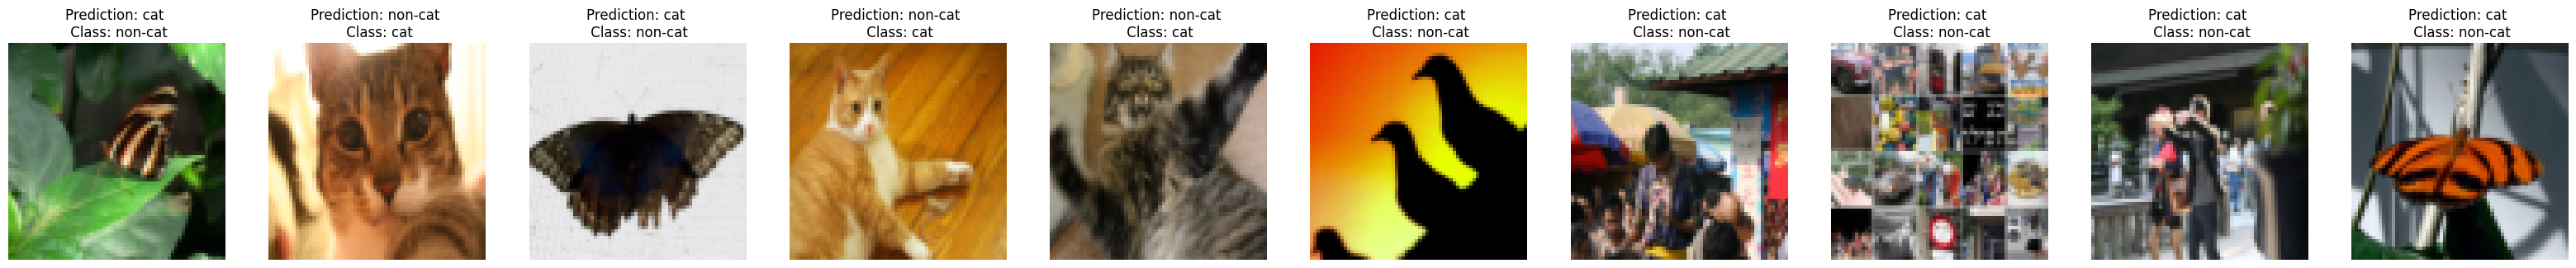

In [34]:
print_mislabeled_images(classes, test_x, test_y, pred_test)

Accuracy: 0.0
y = 1.0, your L-layer model predicts a "cat" picture.


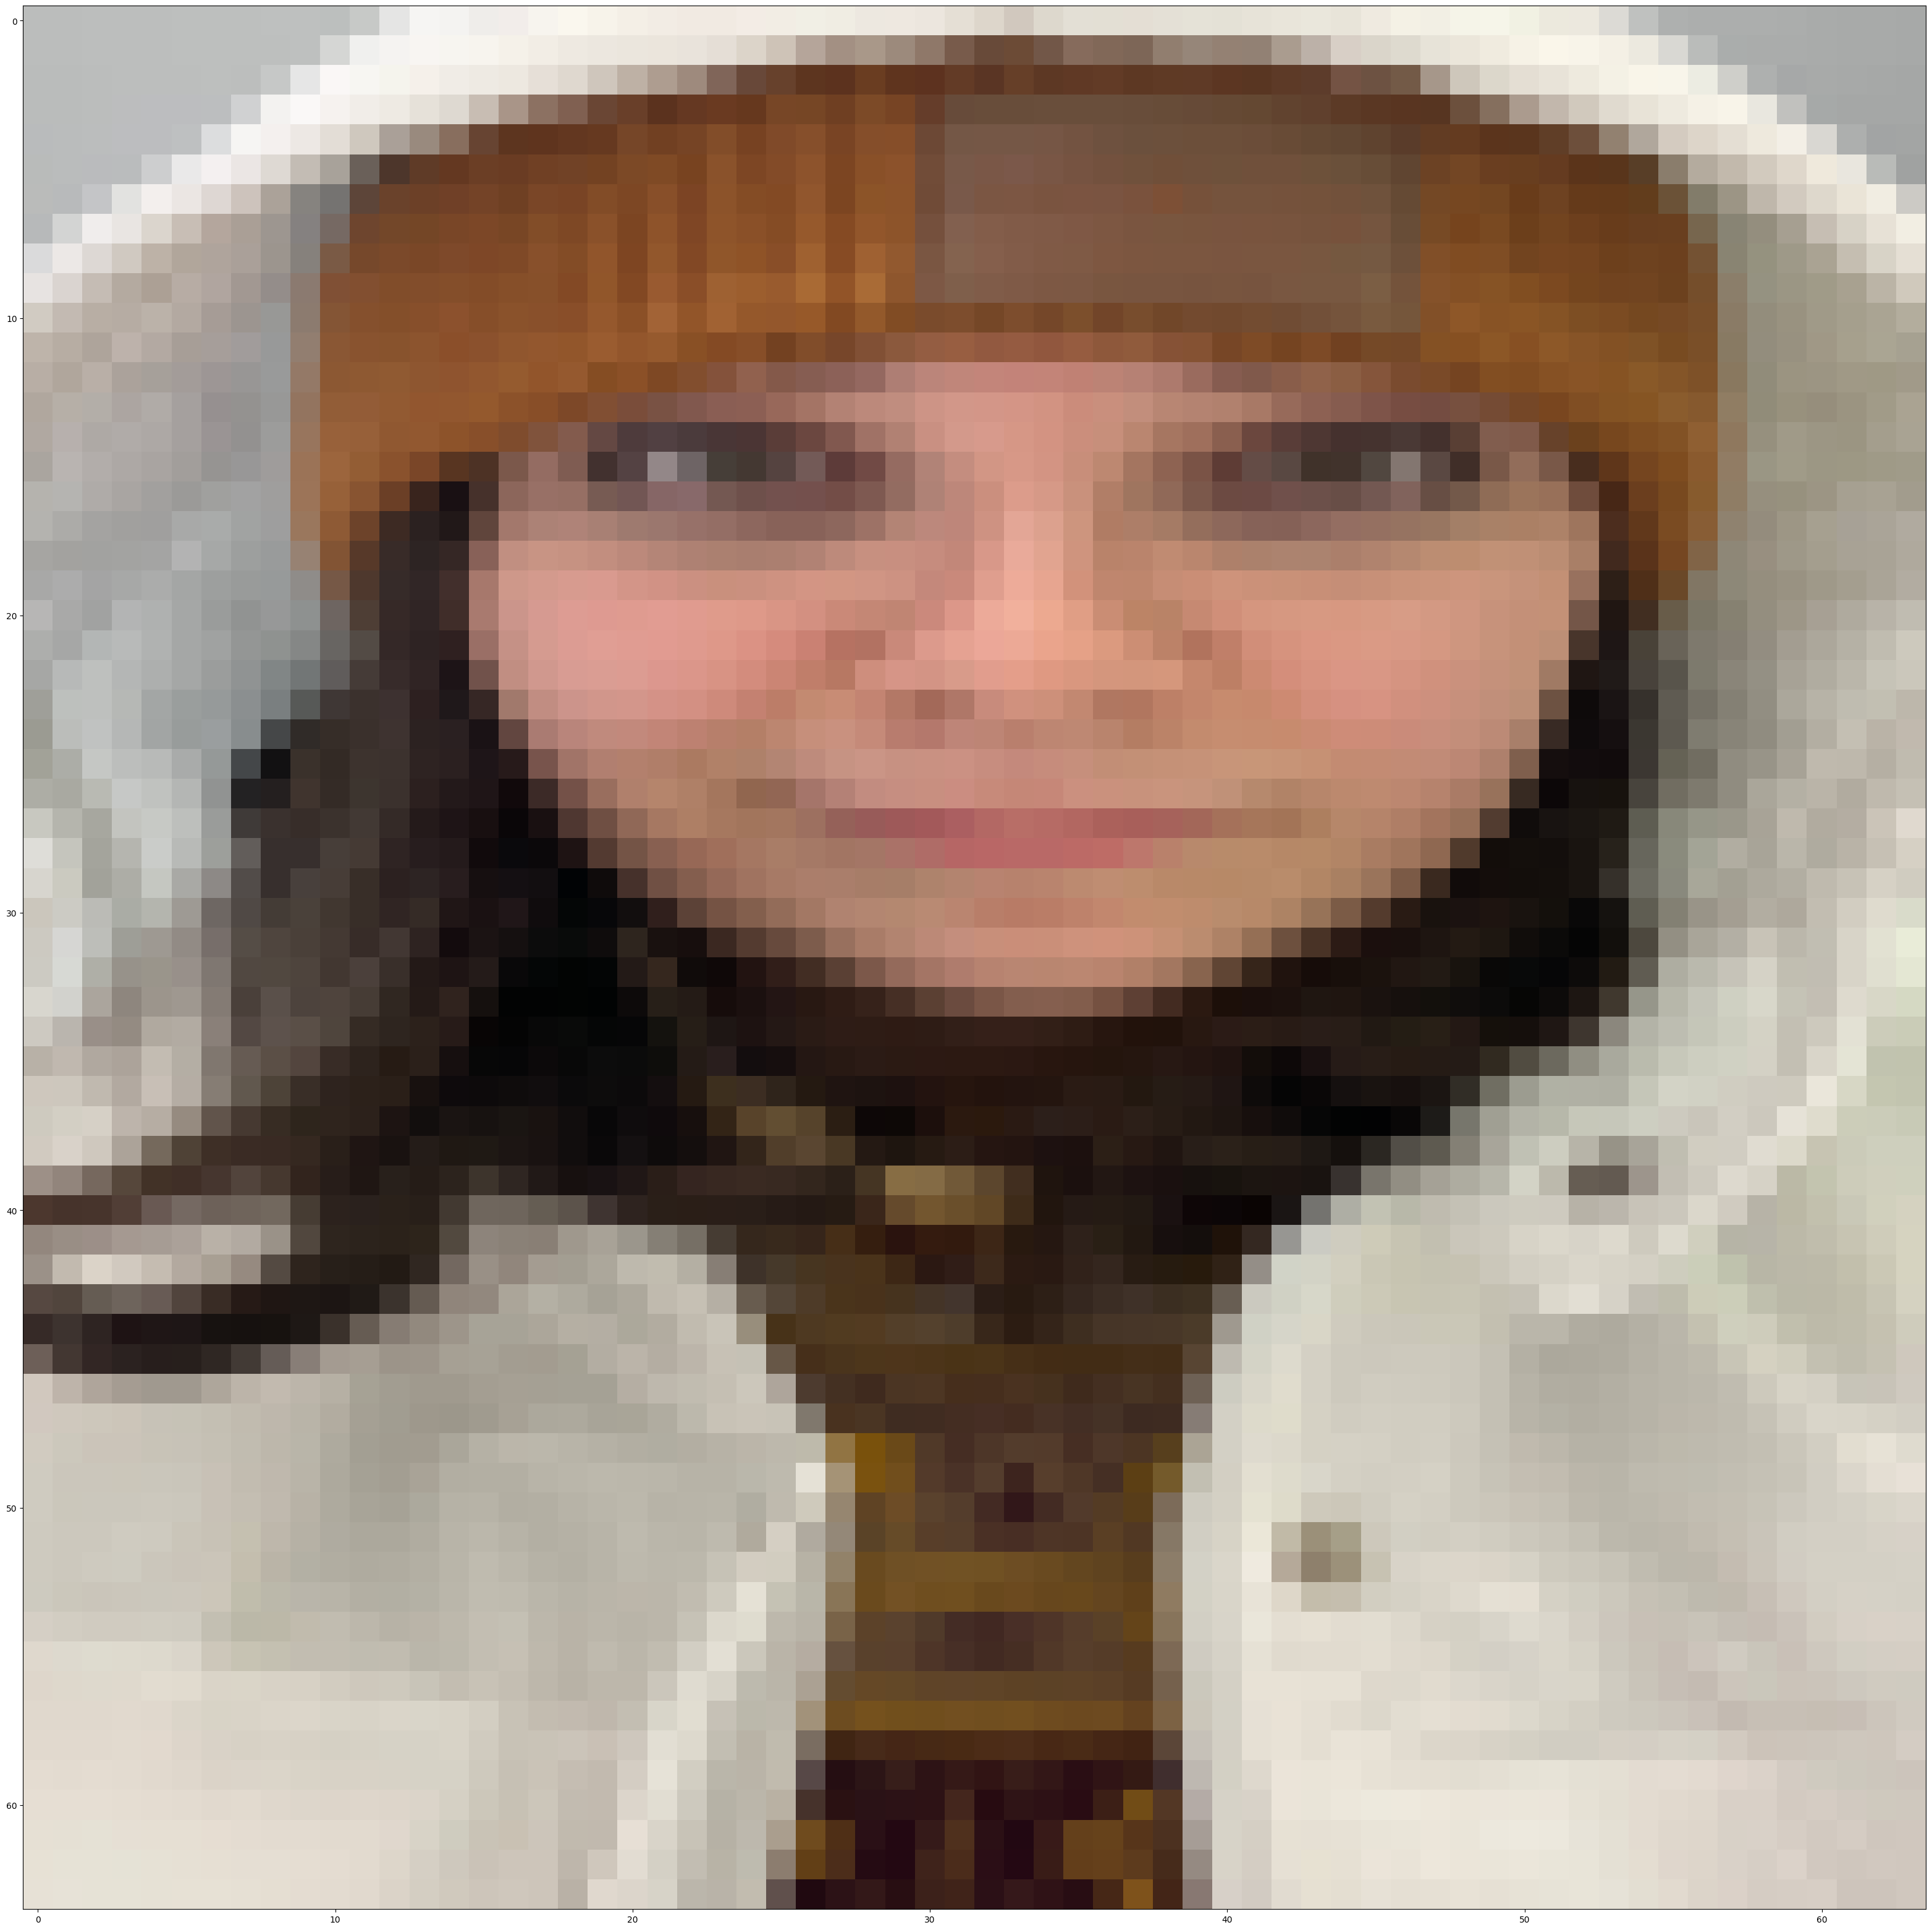

In [47]:
my_image = "IMG_1246.jpg" # change this to the name of your image file 
my_label_y = [0] # the true class of your image (1 -> cat, 0 -> non-cat)

fname = "images/" + my_image
image = np.array(Image.open(fname).resize((num_px, num_px)))
plt.imshow(image)
image = image / 255.
image = image.reshape((1, num_px * num_px * 3)).T

my_predicted_image = predict(image, my_label_y, parameters)

print ("y = " + str(np.squeeze(my_predicted_image)) + ", your L-layer model predicts a \"" + classes[int(np.squeeze(my_predicted_image)),].decode("utf-8") +  "\" picture.")

Another 4 layer network

In [56]:
layers_dims = [12288, 32, 16, 8, 1]

In [63]:
parameters, costs = L_layer_model(train_x, train_y, layers_dims, num_iterations = 2500, print_cost = True)

Cost after iteration 0: 0.6941771667400274
Cost after iteration 100: 0.647066456452343
Cost after iteration 200: 0.6353053926451934
Cost after iteration 300: 0.6185237450225435
Cost after iteration 400: 0.5904209648824769
Cost after iteration 500: 0.5489881827342978
Cost after iteration 600: 0.49109470951387124
Cost after iteration 700: 0.4267462707311665
Cost after iteration 800: 0.4072556720644111
Cost after iteration 900: 0.3759994674192362
Cost after iteration 1000: 0.3260509404310679
Cost after iteration 1100: 0.27013574234071586
Cost after iteration 1200: 0.14732863610060698
Cost after iteration 1300: 0.5010936611125735
Cost after iteration 1400: 0.06572239256044415
Cost after iteration 1500: 0.03953036623241482
Cost after iteration 1600: 0.026676040113796134
Cost after iteration 1700: 0.01964682391751002
Cost after iteration 1800: 0.015059281888094174
Cost after iteration 1900: 0.011957331429626584
Cost after iteration 2000: 0.009770708222174693
Cost after iteration 2100: 0.0081

In [64]:
pred_train = predict(train_x, train_y, parameters)

Accuracy: 0.9999999999999998


In [65]:
pred_test = predict(test_x, test_y, parameters)

Accuracy: 0.8
